#### A. IMPORT ESSENTIAL LIBRARIES & LOAD DATASET

In [2]:
# Import Essential Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Paths
scripts_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/notebooks/eda_src"
data_exploration_path = "/Users/josephyamin/Desktop/Workfolio/Marketing & Advertising/ad_click_prediction_model/data/exploration"

In [4]:
# Import Eda Libraries
os.chdir(scripts_path)
from exploration import coeff_var_skew, num_uni_hist_box
from ml_eda import plot_elbow_method_knn, confusion_matrix_display, classification_report_display, roc_curve_display

In [5]:
# Import Advanced Libraries
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, confusion_matrix, classification_report, roc_curve, auc

In [6]:
# Load & Copy Dataset
os.chdir(data_exploration_path)
original_df = pd.read_csv("eda_processed_data.csv")
df = original_df.copy()

In [7]:
# First Column Drop
df.drop(columns='Unnamed: 0',inplace=True)

In [8]:
# Dataset Sample
df.sample(3)

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Day,Month,IsWeekend,Regions,Topic Group
111,6.324,53,65229.13,94.312,1,1,6,7,1,Asia,0
202,3.565,40,31265.75,69.032,1,1,1,5,0,Asia,5
167,8.606,31,53767.12,87.888,1,0,3,4,0,Asia,3


#### B. FEATURE ENGINEERING

In [10]:
# Missing Value Check
df.isnull().sum()

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
Day                         0
Month                       0
IsWeekend                   0
Regions                     0
Topic Group                 0
dtype: int64

In [11]:
# Area Income: Transformation
df['Area Income_Square'] = np.power(df['Area Income'], 2) # Square

data_positive = df['Area Income']- np.min(df['Area Income']) + 1 # Box Plot
df['Area Income_Boxcox'], _ = boxcox(data_positive)

pt = PowerTransformer(method='yeo-johnson') # Yeo Johnson
df['Area Income_YeoJohnson'] = pt.fit_transform(df[['Area Income']])

In [12]:
# Select Area Income Columns
area_income_ncol = ['Area Income','Area Income_Square','Area Income_Boxcox','Area Income_YeoJohnson']

In [13]:
coeff_var_skew(df,area_income_ncol)

Column:         Area Income
Mean:           55,000.00
Std Dev:        13,414.63
CV:             0.24
Interpretation: The data has low spread.
Skewness:       -0.65
Skew Interpretation: The data is moderately left-skewed.
----------------------------------------
Column:         Area Income_Square
Mean:           3,204,772,462.35
Std Dev:        1,376,230,319.74
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.10
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_Boxcox
Mean:           3,174,812.96
Std Dev:        1,358,001.31
CV:             0.43
Interpretation: The data has low spread.
Skewness:       -0.28
Skew Interpretation: The data is approximately symmetric.
----------------------------------------
Column:         Area Income_YeoJohnson
Mean:           0.00
Std Dev:        1.00
CV:             4693596997336096.00
Interpretation: The data is highly spread relative to the mea

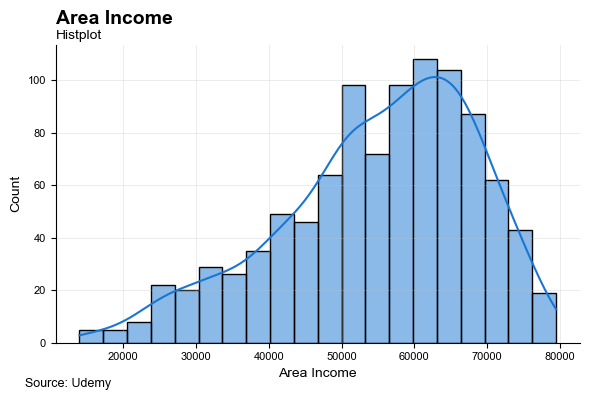

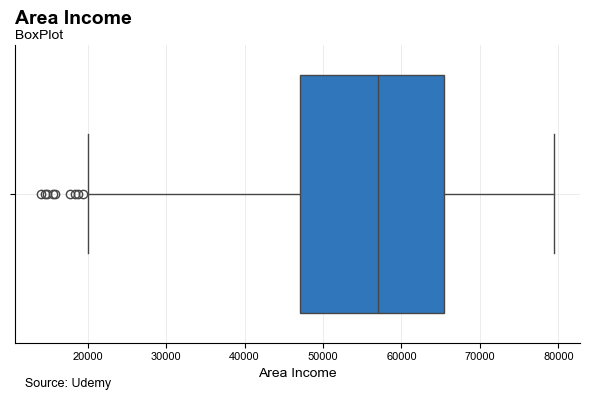

****************************************


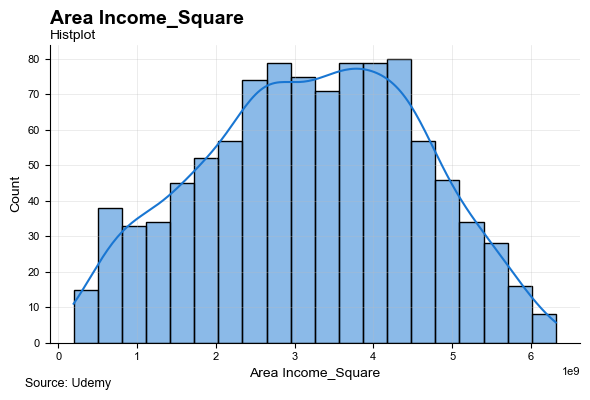

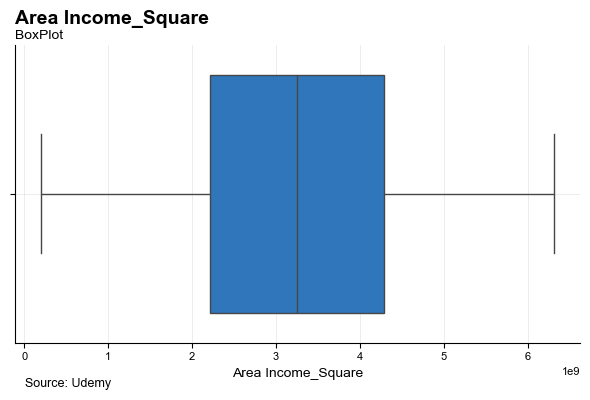

****************************************


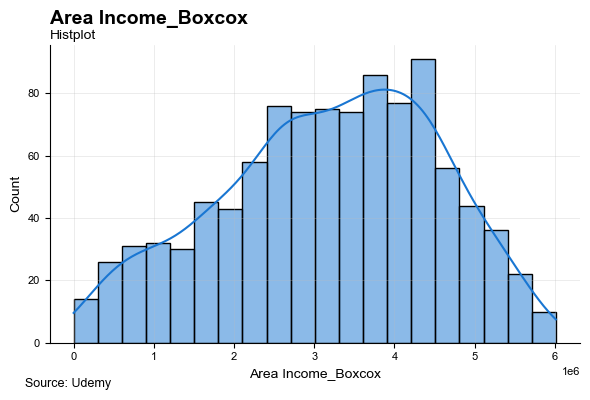

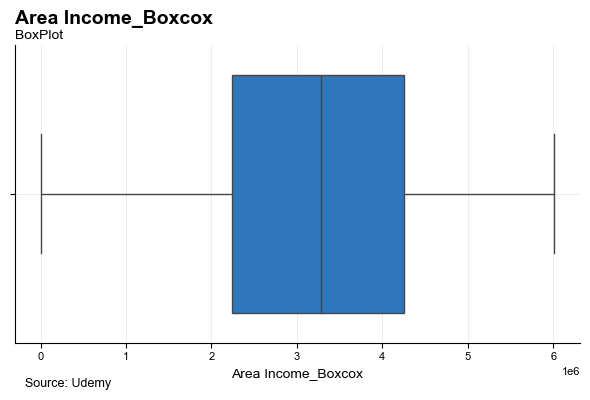

****************************************


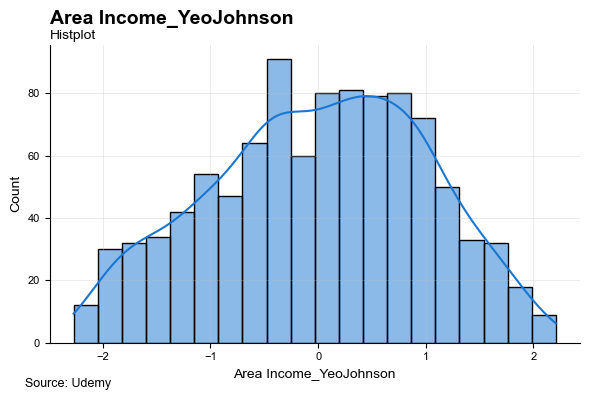

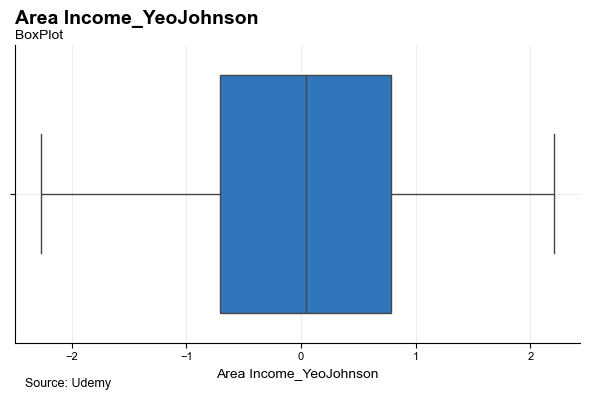

****************************************


In [14]:
# Univeriate Hisplot & Boxplot Display: Area Income
num_uni_hist_box(df,area_income_ncol)

In [15]:
# Drop Unwanted Transformation
df.drop(columns={'Area Income_Boxcox','Area Income_YeoJohnson'},inplace=True)

In [16]:
# Columns for Encoding
encoded_ncol = ['Day','Month','Regions','Topic Group']

In [17]:
# Encoded Dataset
df_encoded = pd.get_dummies(df, columns=encoded_ncol)

In [18]:
# Convert Booleans
df_processed = df_encoded.astype(int).copy()

#### C. KNN: ELBOW METHOD (ALL FEATURES)

In [20]:
# Define Columns
selected_col = df_processed.columns
target_column = 'Clicked on Ad'

In [21]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [22]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [23]:
# Load Scaler
scaler = StandardScaler()

In [24]:
# Scale Fit Data
scaler.fit(X_train)

StandardScaler()

In [25]:
# Scale Transform Data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

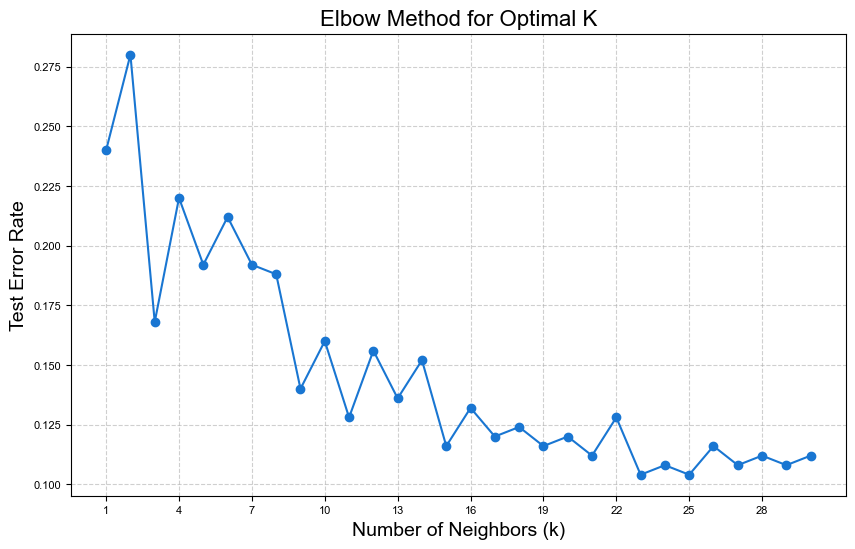

In [26]:
# Visualize Elbow Method
plot_elbow_method_knn(X_train, y_train, X_test, y_test, k_range=30)

#### D. KNN: ML ENGINEERING

In [28]:
# Define Columns: Referencing Logistic Regression
selected_col = ['Daily Internet Usage','Daily Time Spent on Site','Age','Area Income_Square',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [29]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [30]:
# Train, Test, Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [31]:
# Load Scaler
scaler = StandardScaler()

In [32]:
# Scale Fit Data
scaler.fit(X_train)

StandardScaler()

In [33]:
# Scale Transform Data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# Load Model
knn = KNeighborsClassifier()

In [35]:
# Param Grid
param_grid = {
    'n_neighbors': range(1, 30),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [36]:
# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 116 candidates, totalling 580 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': range(1, 30),
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [37]:
# Best Model
best_model = grid_search.best_estimator_

In [38]:
# Print Best Parameters and best score
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation Accuracy: 0.9733 ± 0.0179


In [39]:
# Best Model
best_model = grid_search.best_estimator_

In [40]:
# Prediction
y_pred = best_model.predict(X_test)

In [41]:
# Predict Probabililty
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

In [42]:
# Classification Report
classification_report_display(y_test,y_pred)

Classification Report:
----------------------------------------
              precision    recall  f1-score  support
0              0.907692  0.983333     0.944  120.000
1              0.983333  0.907692     0.944  130.000
accuracy       0.944000  0.944000     0.944    0.944
macro avg      0.945513  0.945513     0.944  250.000
weighted avg   0.947026  0.944000     0.944  250.000


In [43]:
# Confussion Matrix
confusion_matrix_display(y_test, y_pred, labels=['Class 0', 'Class 1'])

Confusion Matrix:
----------------------------------------
                Predicted Class 0  Predicted Class 1
Actual Class 0                118                  2
Actual Class 1                 12                118


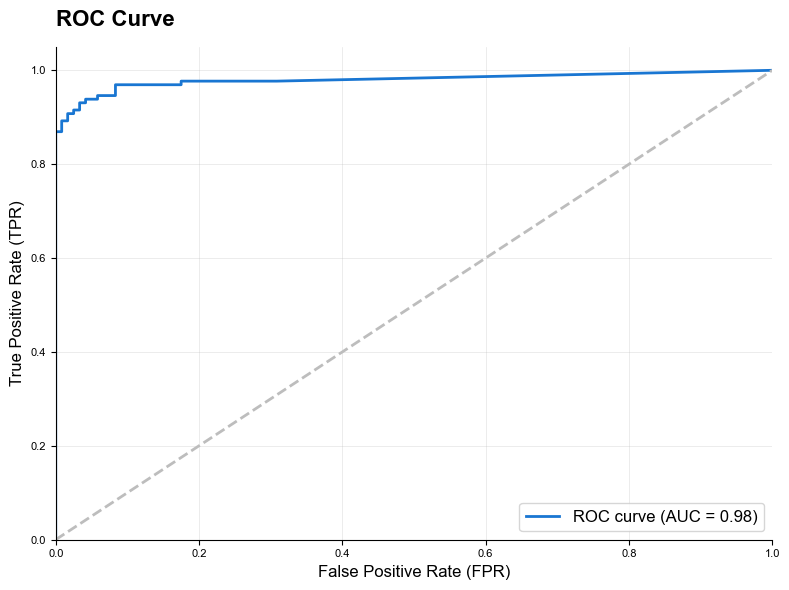

In [44]:
# ROC & AUC Curve
roc_curve_display(y_test, y_pred_prob, plot_title="ROC Curve")

In [45]:
# Background Dataset
background_data = shap.kmeans(X_train, 50)  

In [46]:
# Shape Explainer
explainer = shap.KernelExplainer(best_model.predict_proba, background_data)
shap_values = explainer.shap_values(X_test, nsamples=100)

  0%|          | 0/250 [00:00<?, ?it/s]

In [47]:
# Shap Values Class 1
shap_values_class_1 = shap_values[:, :, 1]

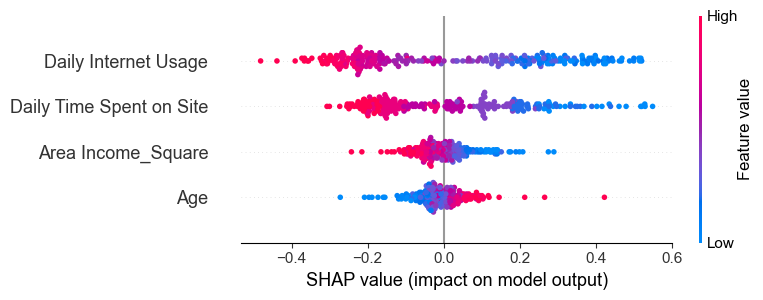

In [48]:
# Visualize Shap Plot 1
shap.summary_plot(shap_values_class_1, X_test, feature_names=X.columns.tolist())

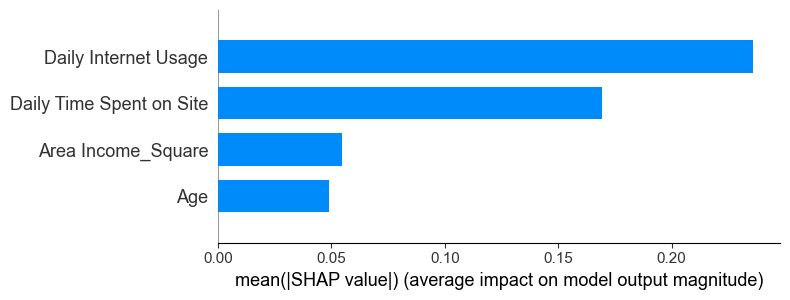

In [49]:
# Visualize Shap Plot 2
shap.summary_plot(shap_values_class_1, X_test, feature_names=X.columns.tolist(),plot_type="bar")

#### E. KNN: FINAL MODEL

In [51]:
# Define Columns
selected_col = ['Daily Internet Usage','Daily Time Spent on Site','Age','Area Income_Square',
                'Clicked on Ad']

target_column = 'Clicked on Ad'

In [52]:
# Set X/y
X = df_processed[selected_col].drop(target_column, axis=1)
y = df_processed[target_column].to_numpy()

In [53]:
# Load Scaler
scaler = StandardScaler()

In [54]:
# Scale Fit Data
scaler.fit(X)

StandardScaler()

In [55]:
# Scale Transform Data
X = scaler.transform(X)

In [56]:
# Final Model Load
final_model = KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights='distance')

In [57]:
# Final Model Fit
final_model.fit(X, y)

KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights='distance')

In [58]:
# New Values
Daily_Internet_Usage = 0
Daily_Time_Spent_on_Site = 0
Age = 48
Area_Income_Square = np.power(24593, 2)


data = {
    'Daily Internet Usage': [Daily_Internet_Usage],
    'Daily Time Spent on Site': [Daily_Time_Spent_on_Site],
    'Age': [Age],
    'Area Income_Square': [Area_Income_Square],
}

new_pred = pd.DataFrame(data)
new_pred

,Daily Internet Usage,Daily Time Spent on Site,Age,Area Income_Square
0,0,0,48,604815649


In [59]:
# Scale New Predictions
new_pred = scaler.transform(new_pred)

In [60]:
# Predict Probabililty of Clicking
prob_class_0 = round(float(final_model.predict_proba(new_pred)[0][0]*100),2)
prob_class_1 = round(float(final_model.predict_proba(new_pred)[0][1]*100),2)
print(f"\033[1m- Probability of Class 0:\033[0m {prob_class_0}%")
print(f"\033[1m- Probability of Class 1:\033[0m {prob_class_1}%")

- Probability of Class 0: 0.0%
- Probability of Class 1: 100.0%
